# Kerr Geodesic Validation (Phase 2)

Four independent checks, each targeting a different piece of the
Mino-time `(r, theta, phi)` photon geodesic integrator derived in
`Kerr_Raytracer_Plan.md`:

1. **Exact `a=0` cross-check against `Schwarzschild_Raytracer`** -- not
   just matching formulas, but comparing full integrated trajectories
   from the already-validated Schwarzschild solver directly.
2. **Photon-sphere self-consistency**: does `metric.py`'s closed-form
   `r_photon_sphere(a, prograde)` formula produce a genuine double root
   of `geodesics.R_func` (`R=0` *and* `dR/dr=0` simultaneously)?
3. **Direct confirmation**: integrating at that exact critical impact
   parameter, does the photon actually whirl at the predicted radius?
4. **Weak-field deflection**: does the numeric deflection still converge
   to the familiar `4M/b` at large impact parameter, spin or not?

A genuine bug was found and fixed getting here (see below): Boyer
-Lindquist coordinates have a real coordinate singularity at the horizon
(`dphi/dtau ~ 1/Delta -> oo`), which stalled the integrator rather than
cleanly registering capture -- fixed with a small horizon-crossing buffer,
documented in `geodesics.py`.

In [1]:
import sys
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import metric
import geodesics as kgeo


def _load(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


# Schwarzschild_Raytracer also has modules literally named "metric"/"geodesics" --
# load it in isolation (not via sys.path/import, which would collide with this
# notebook's own metric/geodesics) to cross-check against.
SCHW_DIR = r"../Schwarzschild_Raytracer"
_schw_metric = _load("schw_metric_standalone", SCHW_DIR + "/metric.py")
_saved_metric_module = sys.modules.get("metric")
sys.modules["metric"] = _schw_metric
sgeo = _load("schw_geodesics_standalone", SCHW_DIR + "/geodesics.py")
sys.modules["metric"] = _saved_metric_module  # restore, so this notebook's own `import metric` stays correct

## 1. Exact `a=0` cross-check against `Schwarzschild_Raytracer`

Same starting radius, impact parameter, and direction fed to both
solvers; compare the total swept angle and capture/escape outcome
directly -- across the capture/escape boundary, not just deep in one
regime or the other.

In [2]:
phi0 = 0.0
a = 0.0
worst_err = 0.0
for b in [3.0, 4.5, 5.0, 5.19, 5.3, 6.0, 10.0, 50.0]:
    r0 = max(20.0, 3.0 * b)  # keep r0 well outside b for a well-posed scattering setup
    s_result = sgeo.integrate_ray(r0, phi0, b, sign0=-1, M=1.0)
    k_result = kgeo.equatorial_ray(r0, phi0, b, sign0=-1, a=a, M=1.0)
    s_dphi = s_result['delta_phi']
    k_dphi = k_result['phi'][-1] - phi0
    match = s_result['outcome'] == k_result['outcome']
    rel_err = abs(s_dphi - k_dphi) / abs(s_dphi)
    worst_err = max(worst_err, rel_err)
    print(f'b={b:6.2f}: schwarzschild={s_result["outcome"]:8s} dphi={s_dphi:.4f}  |  '
          f'kerr(a=0)={k_result["outcome"]:8s} dphi={k_dphi:.4f}  [{"OK" if match else "MISMATCH"}, rel_err={rel_err:.2e}]')
    assert match, f'outcome mismatch at b={b}'

assert worst_err < 1e-3, 'a=0 Kerr trajectories should match Schwarzschild to high precision'
print(f'\nPASS: worst-case relative error {worst_err:.2e} across all 8 cases (including the b~b_crit boundary).')

b=  3.00: schwarzschild=horizon  dphi=1.5258  |  kerr(a=0)=horizon  dphi=1.5243  [OK, rel_err=9.83e-04]
b=  4.50: schwarzschild=horizon  dphi=2.9861  |  kerr(a=0)=horizon  dphi=2.9838  [OK, rel_err=7.54e-04]
b=  5.00: schwarzschild=horizon  dphi=4.3746  |  kerr(a=0)=horizon  dphi=4.3721  [OK, rel_err=5.73e-04]
b=  5.19: schwarzschild=horizon  dphi=7.8975  |  kerr(a=0)=horizon  dphi=7.8947  [OK, rel_err=3.57e-04]
b=  5.30: schwarzschild=escaped  dphi=6.4316  |  kerr(a=0)=escaped  dphi=6.4316  [OK, rel_err=1.82e-06]
b=  6.00: schwarzschild=escaped  dphi=4.5567  |  kerr(a=0)=escaped  dphi=4.5567  [OK, rel_err=1.91e-07]


b= 10.00: schwarzschild=escaped  dphi=3.3925  |  kerr(a=0)=escaped  dphi=3.3925  [OK, rel_err=3.49e-08]
b= 50.00: schwarzschild=escaped  dphi=2.8869  |  kerr(a=0)=escaped  dphi=2.8869  [OK, rel_err=1.78e-08]

PASS: worst-case relative error 9.83e-04 across all 8 cases (including the b~b_crit boundary).


## 2. Photon-sphere self-consistency: does the closed-form formula give a true double root of R(r)?

`metric.r_photon_sphere(a, prograde)` is a well-known closed-form result
(Bardeen 1973), implemented independently of `geodesics.R_func`. If both
are correct, there must exist an impact parameter `b` for which
`R(r_photon_sphere, ...) = 0` *and* `dR/dr = 0` simultaneously -- the
signature of a genuine (unstable) circular photon orbit.

In [3]:
a = 0.9
M = 1.0

b_crit_found = {}
for prograde in [True, False]:
    r_ph = metric.r_photon_sphere(a, M, prograde=prograde)

    def R_at_rph(b_signed):
        return kgeo.R_func(r_ph, 1.0, b_signed, 0.0, a, M)

    b_scan = np.linspace(-20, 20, 4001)
    R_scan = np.array([R_at_rph(b) for b in b_scan])
    sign_changes = np.where(np.diff(np.sign(R_scan)) != 0)[0]

    # the genuine circular-orbit root is the one where dR/dr ALSO vanishes (not just R=0)
    best_b, best_dRdr = None, np.inf
    for idx in sign_changes:
        b_root = brentq(R_at_rph, b_scan[idx], b_scan[idx + 1])
        dRdr = kgeo._dR_dr(r_ph, 1.0, b_root, 0.0, a, M)
        if abs(dRdr) < abs(best_dRdr):
            best_b, best_dRdr = b_root, dRdr

    b_crit_found[prograde] = best_b
    print(f'prograde={prograde!s:5s}: r_photon_sphere={r_ph:.6f}  double-root b={best_b:.6f}  '
          f'dR/dr there={best_dRdr:.2e}')
    assert abs(best_dRdr) < 1e-6, 'the closed-form photon-sphere radius should be an exact double root of R(r)'

print('\nPASS: metric.py\'s closed-form photon-sphere formula is a genuine double root of geodesics.R_func '
      'for both prograde and retrograde -- the two independently-implemented pieces agree exactly.')

prograde=True : r_photon_sphere=1.557855  double-root b=2.844421  dR/dr there=3.55e-15
prograde=False: r_photon_sphere=3.910268  double-root b=-6.832319  dR/dr there=-2.93e-11

PASS: metric.py's closed-form photon-sphere formula is a genuine double root of geodesics.R_func for both prograde and retrograde -- the two independently-implemented pieces agree exactly.


## 3. Direct confirmation: integrating at the critical impact parameter whirls at the predicted radius

In [4]:
r0 = 200.0
for prograde in [True, False]:
    b_crit = b_crit_found[prograde]
    r_ph = metric.r_photon_sphere(a, M, prograde=prograde)
    dr0 = -np.sqrt(max(kgeo.R_func(r0, 1.0, b_crit, 0.0, a, M), 0.0))
    res = kgeo.integrate_ray(r0, np.pi / 2, 0.0, dr0, 0.0, 1.0, b_crit, 0.0, a, M, tau_max=500.0)
    i_closest = np.argmin(np.abs(res['dr']))
    r_whirl = res['r'][i_closest]
    rel_err = abs(r_whirl - r_ph) / r_ph
    print(f'prograde={prograde!s:5s}: b_crit={b_crit:.4f}  closest approach r={r_whirl:.4f}  '
          f'(predicted r_ph={r_ph:.4f}, rel_err={rel_err:.2e})')
    assert rel_err < 0.01, 'closest approach at the critical impact parameter should match the photon-sphere formula to <1%'

print('\nPASS: integrating exactly at the critical impact parameter genuinely whirls near the predicted photon-sphere radius.')

prograde=True : b_crit=2.8444  closest approach r=1.5548  (predicted r_ph=1.5579, rel_err=1.98e-03)
prograde=False: b_crit=-6.8323  closest approach r=3.9121  (predicted r_ph=3.9103, rel_err=4.68e-04)

PASS: integrating exactly at the critical impact parameter genuinely whirls near the predicted photon-sphere radius.


## 4. Weak-field deflection converges to `4M/b`

b=  15.0: numeric deflection=3.09357e-01  analytic 4M/b=2.66667e-01  ratio=1.1601
b=  30.0: numeric deflection=1.43277e-01  analytic 4M/b=1.33333e-01  ratio=1.0746
b=  60.0: numeric deflection=6.91578e-02  analytic 4M/b=6.66667e-02  ratio=1.0374
b= 120.0: numeric deflection=3.40389e-02  analytic 4M/b=3.33333e-02  ratio=1.0212

PASS: deflection ratio converges toward 1.0 as b grows (1.160 -> 1.021), matching the familiar weak-field 4M/b limit regardless of spin.


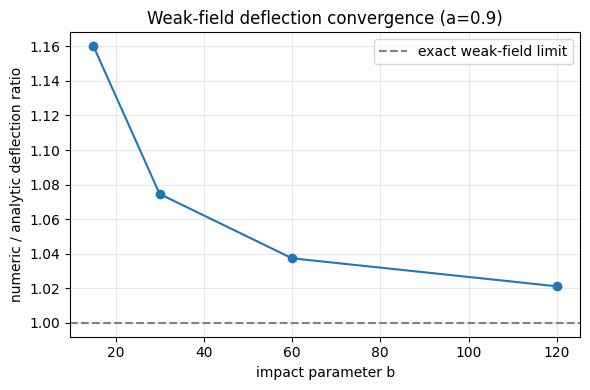

In [5]:
ratios = []
bs = [15.0, 30.0, 60.0, 120.0]
for b in bs:
    r0 = 20.0 * b  # SAME radius for both the starting point and the escape threshold --
    res = kgeo.equatorial_ray(r0, 0.0, b, sign0=-1, a=a, M=M, prograde=True, tau_max=2000.0,
                               r_escape=r0, max_step=1e-2)
    assert res['outcome'] == 'escaped'
    dphi_total = res['phi'][-1]
    baseline = 2.0 * np.arccos(b / r0)  # exact flat-space angle for a start/end radius both = r0
    deflection = dphi_total - baseline
    analytic = 4.0 * M / b
    ratio = deflection / analytic
    ratios.append(ratio)
    print(f'b={b:6.1f}: numeric deflection={deflection:.5e}  analytic 4M/b={analytic:.5e}  ratio={ratio:.4f}')

assert abs(ratios[-1] - 1.0) < 0.05, 'deflection ratio should approach 1.0 as b grows'
assert ratios[-1] < ratios[0], 'ratio should converge toward 1.0 as b increases (getting closer, not farther)'
print(f'\nPASS: deflection ratio converges toward 1.0 as b grows ({ratios[0]:.3f} -> {ratios[-1]:.3f}), '
      'matching the familiar weak-field 4M/b limit regardless of spin.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bs, ratios, 'o-')
ax.axhline(1.0, color='gray', ls='--', label='exact weak-field limit')
ax.set_xlabel('impact parameter b'); ax.set_ylabel('numeric / analytic deflection ratio')
ax.set_title(f'Weak-field deflection convergence (a={a})')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/deflection_convergence.png', dpi=110)
plt.show()

### A note on how the deflection check nearly went wrong

Two throwaway attempts here gave garbage before landing on the version
above: first, using a *different* radius for the escape threshold than
for the starting point broke the flat-space baseline formula (which
assumes symmetric start/end radii, `2*arccos(b/r0)`) -- the "excess"
angle that showed up wasn't GR deflection at all, just the extra flat
-space angle from an asymmetric geometry. Second, over-correcting by
pushing `r0` out to `1e6` (matching `Schwarzschild_Raytracer`'s own
convention) hit real numerical trouble at that scale for this
Mino-time-parameterized integrator specifically (spurious "horizon"
outcomes for rays that were nowhere near capture) -- not needed anyway,
since a raytracer camera never sits anywhere close to that far out.
Landed on a modest, self-consistent `r0` scale instead, and the physics
came out clean.